In [3]:
!pip3 install kaggle

In [4]:
!pip3 install load_dotenv

In [5]:
import os 

from dotenv import load_dotenv

KAGGLE_USERNAME = os.getenv('KAGGLE_USERNAME')
KAGGLE_KEY = os.getenv('KAGGLE_KEY')



In [6]:
!kaggle datasets download -d rakeshkapilavai/extrovert-vs-introvert-behavior-data

Dataset URL: https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data
License(s): CC-BY-SA-4.0
extrovert-vs-introvert-behavior-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
#!unzip extrovert-vs-introvert-behavior-data.zip -d datasets

In [8]:
!pip3 install pandas

##### Data Loading & Cleaning

In [9]:
import pandas as pd

In [10]:
# Load the dataset using pandas.

df = pd.read_csv('datasets/personality_dataset.csv')

In [11]:
# Display the first 10 rows and list all column names
df.head(10)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
5,1.0,No,7.0,5.0,No,6.0,6.0,Extrovert
6,4.0,No,9.0,NaN,No,7.0,7.0,Extrovert
7,2.0,No,8.0,4.0,No,7.0,8.0,Extrovert
8,10.0,Yes,1.0,3.0,Yes,0.0,3.0,Introvert
9,0.0,No,8.0,6.0,No,13.0,8.0,Extrovert


In [12]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [13]:
# Check for missing values per column
df.isna().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [14]:
# Impute missing numerical values with the mean, and categorical with mode
df.dtypes

Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

In [15]:
categorical_columns = ['Stage_fear','Drained_after_socializing']


In [16]:
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
numeric_columns = ['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']

In [18]:
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

In [19]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [20]:
# Convert categorical columns like gender to proper data types

df_encoded = pd.get_dummies(df,columns = ['Stage_fear','Drained_after_socializing','Personality'], drop_first=True).astype(int)
df_encoded.head(5)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes,Personality_Introvert
0,4,4,6,13,5,0,0,0
1,9,0,0,0,3,1,1,1
2,9,1,2,5,2,1,1,1
3,0,6,7,14,8,0,0,0
4,3,9,4,8,5,0,0,0


In [21]:
# Identify and drop duplicate rows.
# Reset index after data cleaning.
df_encoded.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2895     True
2896    False
2897    False
2898    False
2899    False
Length: 2900, dtype: bool

In [22]:
df_encoded.drop_duplicates().reset_index(drop = True)
df_encoded.duplicated().sum()

np.int64(429)

In [23]:
!pip3 install matplotlib

/tmp/ipykernel_6703/2077577931.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']],labels = ['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency'])


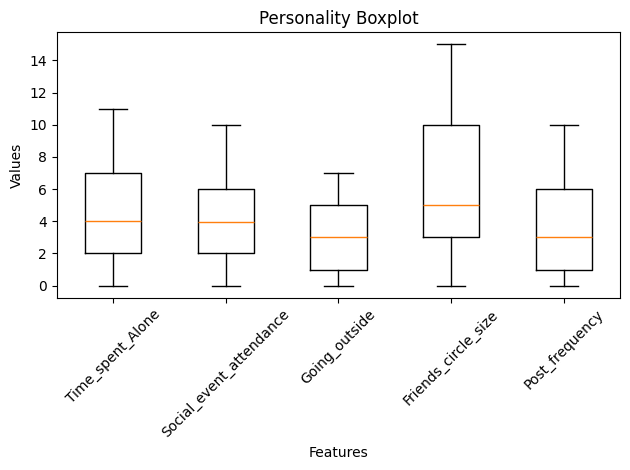

In [24]:
#Use boxplots to find outliers in any numerical column.

import matplotlib.pyplot as plt
plt.boxplot(df[['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']],labels = ['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency'])
plt.xticks(rotation = 45)
plt.title('Personality Boxplot')
plt.ylabel('Values')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

In [25]:
# Remove rows beyond 3 standard deviations from the mean

##### Exploratory Data Analysis (EDA) & Visualizations

##### GroupBy & Aggregation

##### Feature Scaling

In [26]:
df_encoded.dtypes

Time_spent_Alone                 int64
Social_event_attendance          int64
Going_outside                    int64
Friends_circle_size              int64
Post_frequency                   int64
Stage_fear_Yes                   int64
Drained_after_socializing_Yes    int64
Personality_Introvert            int64
dtype: object

In [27]:
df.shape

(2900, 8)

In [28]:
df_encoded.shape

(2900, 8)

In [29]:
# Separate features (X) and target (y).
X = df_encoded.drop(columns=['Personality_Introvert'])
y = df_encoded['Personality_Introvert']
X.shape

(2900, 7)

In [30]:
!pip3 install scikit-learn

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
# Split into training and test sets (70:30)
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.3, random_state=42 )
print(X_train.shape)
print(X_test.shape)

(2030, 7)
(870, 7)


In [33]:
X_train.columns

Index(['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
       'Friends_circle_size', 'Post_frequency', 'Stage_fear_Yes',
       'Drained_after_socializing_Yes'],
      dtype='object')

In [34]:
# Apply StandardScaler to X: fit on train, transform both (Standardization)
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()
standard_df = pd.DataFrame(standard.fit_transform(X_train),columns=['Time_spent_Alone', 'Social_event_attendance', 'Going_outside','Friends_circle_size', 'Post_frequency', 'Stage_fear_Yes','Drained_after_socializing_Yes'])
standard_df

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes
0,-1.021954,0.388340,1.802808,1.132428,1.559248,-0.987273,-0.987273
1,0.133632,-1.008789,-1.335872,-0.285144,-0.872638,1.012891,1.012891
2,1.867013,-1.008789,-1.335872,-0.521406,-1.220050,1.012891,1.012891
3,1.289219,-0.659507,-1.335872,-0.521406,-0.872638,1.012891,1.012891
4,-0.444161,0.039058,1.802808,0.423642,0.517011,-0.987273,-0.987273
...,...,...,...,...,...,...,...
2025,-0.733058,1.086904,0.457660,1.368690,1.559248,-0.987273,-0.987273
2026,-1.310851,1.086904,0.457660,1.841213,0.864423,-0.987273,-0.987273
2027,1.867013,-1.008789,-0.887489,-0.521406,-0.525226,1.012891,1.012891
2028,1.578116,-0.310224,-0.887489,-0.285144,-1.220050,1.012891,1.012891


In [35]:
# Use MinMaxScaler, compare the scaled feature ranges.(Normalisation)
from sklearn.preprocessing import MinMaxScaler

min_max = MinMaxScaler()
min_max_df = pd.DataFrame(min_max.fit_transform(X_train),columns=['Time_spent_Alone', 'Social_event_attendance', 'Going_outside','Friends_circle_size', 'Post_frequency', 'Stage_fear_Yes','Drained_after_socializing_Yes'])
min_max_df


,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes
0,0.090909,0.5,1.000000,0.733333,0.8,0.0,0.0
1,0.454545,0.1,0.000000,0.333333,0.1,1.0,1.0
2,1.000000,0.1,0.000000,0.266667,0.0,1.0,1.0
3,0.818182,0.2,0.000000,0.266667,0.1,1.0,1.0
4,0.272727,0.4,1.000000,0.533333,0.5,0.0,0.0
...,...,...,...,...,...,...,...
2025,0.181818,0.7,0.571429,0.800000,0.8,0.0,0.0
2026,0.000000,0.7,0.571429,0.933333,0.6,0.0,0.0
2027,1.000000,0.1,0.142857,0.266667,0.2,1.0,1.0
2028,0.909091,0.3,0.142857,0.333333,0.0,1.0,1.0


In [36]:
!pip3 install seaborn

In [37]:
import seaborn as sns

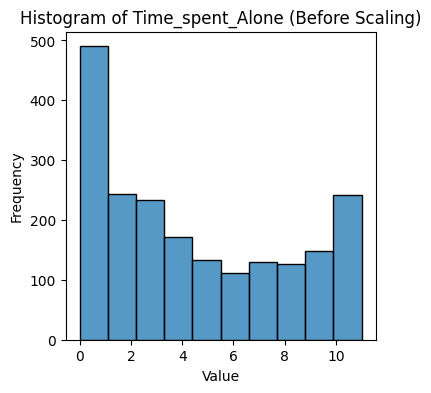

In [38]:
plt.figure(figsize=(4,4))
sns.histplot(X_train['Time_spent_Alone'],bins=10)
plt.title('Histogram of Time_spent_Alone (Before Scaling)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

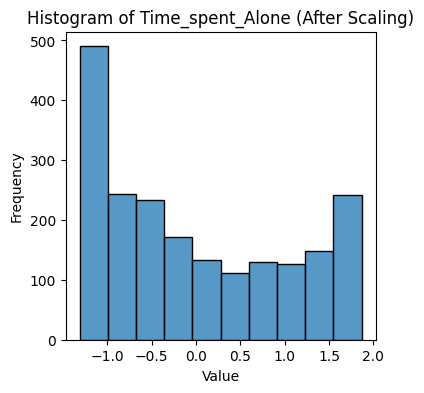

In [39]:
# Plot a histogram of a scaled feature before and after scaling.

#
plt.figure(figsize=(4,4))
sns.histplot(standard_df['Time_spent_Alone'],bins=10)
plt.title('Histogram of Time_spent_Alone (After Scaling)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()


##### Train/Test Split & Baseline Model

In [40]:
# Ensure test set is scaled correctly and has no missing values.

standard = StandardScaler()
X_testdf = pd.DataFrame(standard.fit_transform(X_test),columns=['Time_spent_Alone', 'Social_event_attendance', 'Going_outside','Friends_circle_size', 'Post_frequency', 'Stage_fear_Yes','Drained_after_socializing_Yes'])
X_testdf

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes
0,1.652294,-0.368954,-0.021951,-0.328734,-0.220557,1.064121,1.071517
1,-0.116569,-0.368954,0.887445,1.800288,0.462307,-0.939743,-0.933257
2,0.178242,-1.403294,-1.386045,-1.511524,-0.561989,1.064121,1.071517
3,1.652294,-0.713734,-0.476649,-1.038408,-0.903421,1.064121,1.071517
4,0.767863,-1.403294,-1.386045,-1.038408,-0.903421,1.064121,1.071517
...,...,...,...,...,...,...,...
865,-0.411379,0.665386,0.432747,1.563730,-0.220557,-0.939743,-0.933257
866,0.767863,-1.403294,-0.476649,-1.038408,-1.244853,1.064121,1.071517
867,1.062673,-1.403294,-0.476649,-0.565292,-0.903421,1.064121,1.071517
868,-0.706190,0.320606,1.342143,0.617498,1.828034,-0.939743,-0.933257


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [42]:
# Train a Logistic Regression classifier.
lr = LogisticRegression()
model = lr.fit(X_train,y_train)
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [43]:
# Evaluate: accuracy, precision, recall, F1-score.
y_pred = lr.predict(X_test)

classrep = classification_report(y_test,y_pred)
print(classrep)

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       463
           1       0.91      0.93      0.92       407

    accuracy                           0.93       870
   macro avg       0.92      0.93      0.93       870
weighted avg       0.93      0.93      0.93       870



In [44]:
#Plot the confusion matrix.
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[427,  36],
       [ 29, 378]])

In [ ]:
# Explain any signs of class imbalance or bias.